# Popular repositories to study:
- UC Irvire Machine Learning Repository: https://archive.ics.uci.edu/ml/index.php
- Kaggle Datasets: https://www.kaggle.com/datasets
- AWS Open Data: https://registry.opendata.aws/

# Metaportal data:
- Data Portal: https://data.metaportal.org/
- Open Data Monitor: https://data.metaportal.org/open-data-portal
- Quandl: https://www.quandl.com/


# Data Scientists must to do at first the check list project:
- What is the goal of the project?
- What is the benefit for the company?
- What is the data that I have?
- How to measure the performance of the model?

# Opening the dataset:

In [1]:
import os
import tarfile
import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

import pandas as pd
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

fetch_housing_data()
housing = load_housing_data()

In [2]:
housing.head()
housing.info()
housing.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


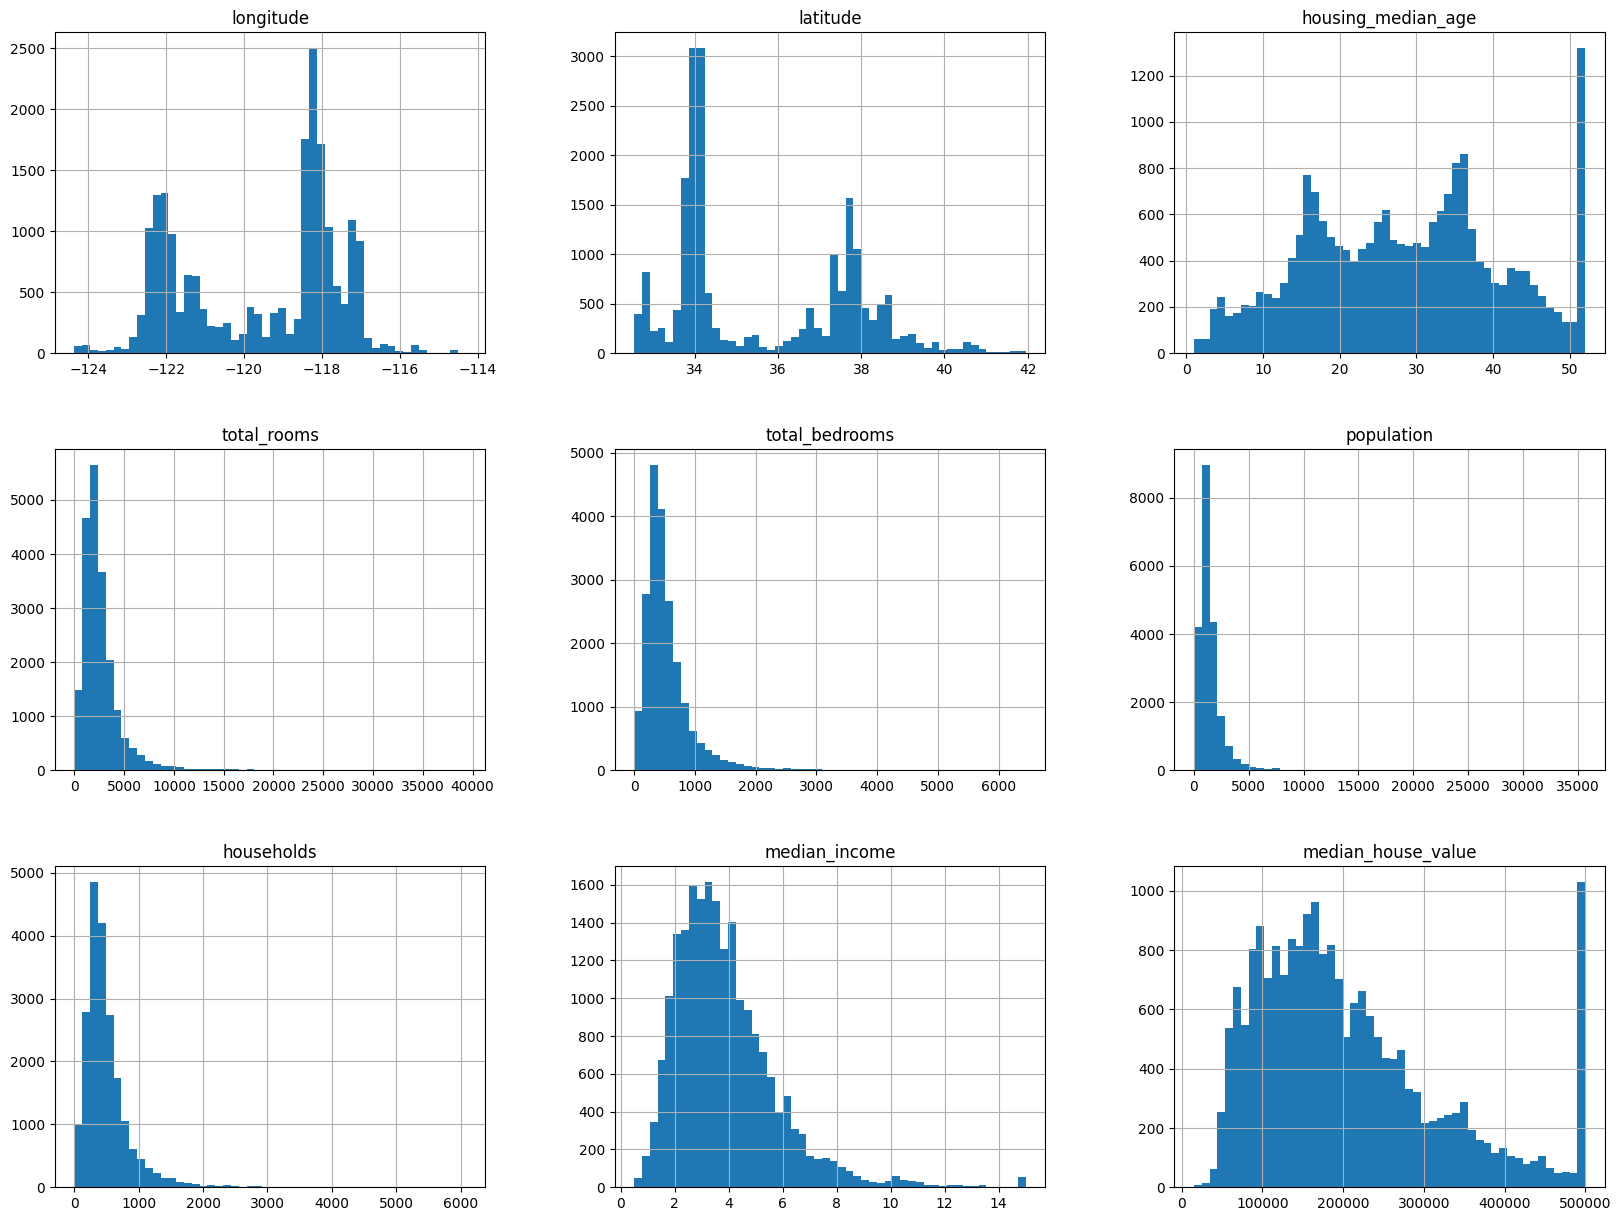

In [3]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

# Test data snipping:
- It means to take a small portion of the data to understand its structure and content before processing the entire dataset. This helps in identifying any issues or patterns in the data early on.

In [4]:
import numpy as np
from zlib import crc32


def split_train_test(data, test_ratio):
    """Split a dataset into randomized train and test sets.

    Args:
        data (pandas.DataFrame): Input dataset to split.
        test_ratio (float): Fraction of rows to include in the test set.

    Returns:
        tuple[pandas.DataFrame, pandas.DataFrame]: A tuple containing the
        training set and the test set.
    """
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


def test_set_check(identifier, test_ratio):
    """Decide whether a row identifier should belong to the test set.

    Uses a CRC32 hash for a deterministic split so the same identifier is
    consistently assigned to the same subset across runs.

    Args:
        identifier (int): Row identifier used for deterministic hashing.
        test_ratio (float): Fraction of rows that should be in the test set.

    Returns:
        bool: True if the identifier is assigned to the test set,
        otherwise False.
    """
    return crc32(np.int64(identifier)) & 0xFFFFFFFF < test_ratio * 2**32


def split_train_test_by_id(data, test_ratio, id_column):
    """Split a dataset into train and test sets using stable row IDs.

    This method avoids train/test leakage caused by reshuffling because
    assignment depends on deterministic hashing of each row ID.

    Args:
        data (pandas.DataFrame): Input dataset to split.
        test_ratio (float): Fraction of rows to include in the test set.
        id_column (str): Name of the column containing unique row IDs.

    Returns:
        tuple[pandas.DataFrame, pandas.DataFrame]: A tuple containing the
        training set and the test set.
    """
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]


housing_with_id = housing.reset_index()  # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")
print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}")

Rows in train set: 16512
Rows in test set: 4128


# Rando seed concept:
- A random seed is a value used to initialize a pseudorandom number generator.
- It ensures that the sequence of random numbers generated is reproductible, meaning that the same seed will produce the same sequence of random numbers.
- This is important for `reproducibility` in machine learning experiments, as it allows others to replicate

In [5]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}")

Rows in train set: 16512
Rows in test set: 4128


# pd.cut():
- It is a function in pandas that is used to segment and sort data values into bins or categories. 
- It is often used for creating categorical variables from continuous data.

<Axes: >

<Axes: >

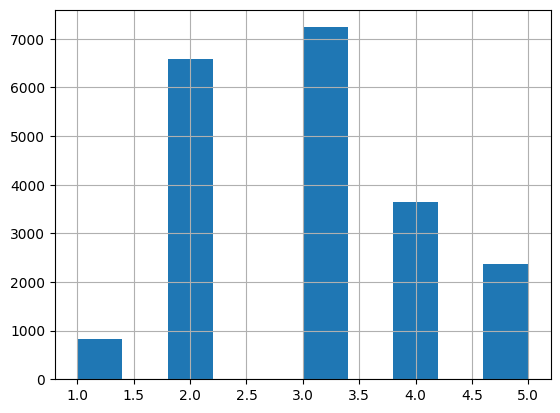

In [6]:
housing["income_cat"] = pd.cut(housing["median_income"],
                            bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                            labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()

# Stratificated shuffling:
- It is a technique used in machine learning to ensure that the distribution of classes in the training and testing datasets is similar to the distribution in the original dataset.
- This is important to prevent bias in the model and to ensure that the model generalizes well to unseen data.

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [8]:
for set in (strat_train_set, strat_test_set):
    set.drop("income_cat", axis=1, inplace=True)

# Seeing the Data:

<Axes: xlabel='longitude', ylabel='latitude'>

<Axes: xlabel='longitude', ylabel='latitude'>

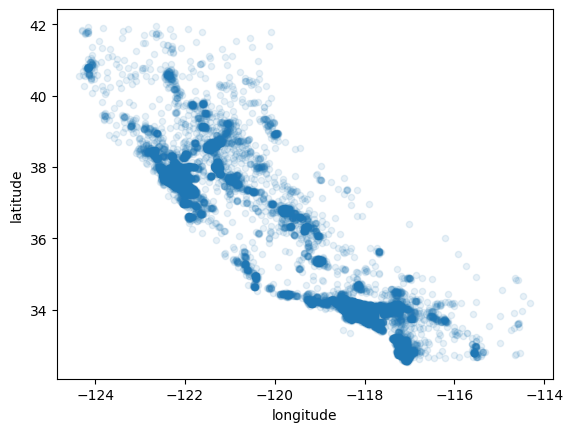

In [9]:
housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)


<Axes: xlabel='longitude', ylabel='latitude'>

<Axes: xlabel='longitude', ylabel='latitude'>

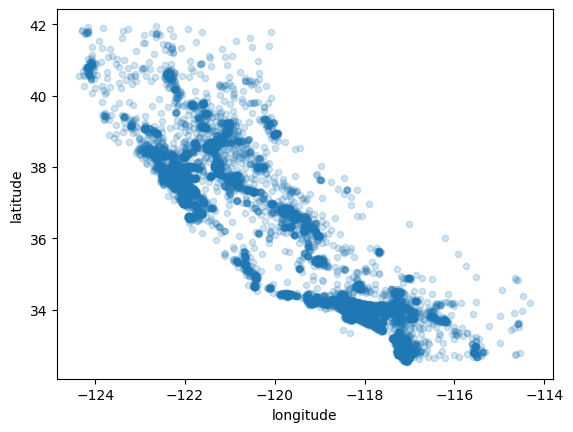

In [10]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.2)

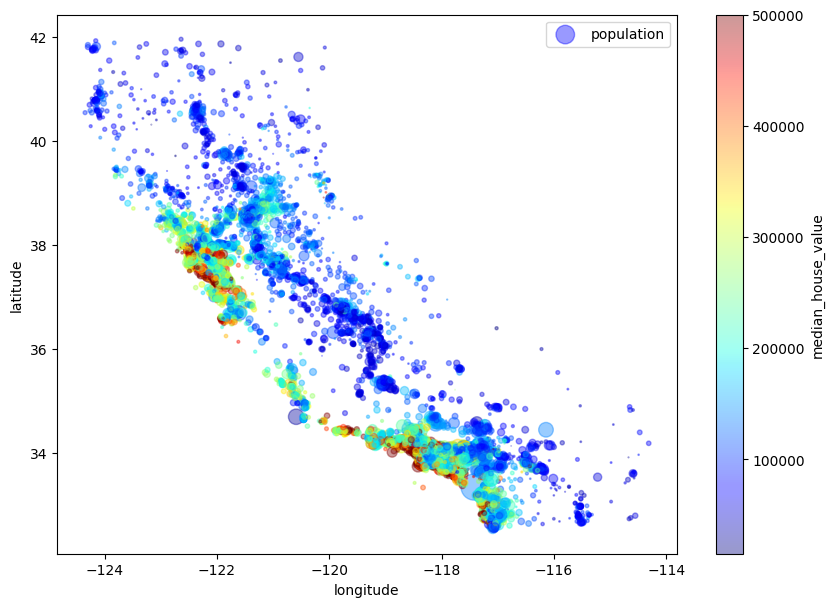

In [11]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"]/100, label="population", figsize=(10, 7), c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

# Looking for correlations Person:
- Correlation is a statistical measure that indicates the extent to which two or more variables fluctuate together.
- A positive correlation means that as one variable increases, the other variable also increases. 
- A negative correlation means that as one variable increases, the other variable decreases.
    - Table correlation: A table that shows the correlation coefficients between different variables in a dataset.
        ## Looking for correlations
        - Correlation measures how two variables move together.
        - Positive correlation: when one variable increases, the other tends to increase.
        - Negative correlation: when one variable increases, the other tends to decrease.
        - Common tools:
        - Correlation table (matrix): shows correlation coefficients between variables.
        - Scatter plot: visualizes the relationship between two variables.

        ## Correlation strength guide (10 ranges from -1 to 1)
        | Correlation range (r) | Direction | Strength |
        |---|---|---|
        | [-1.0, -0.8] | Negative | Very strong |
        | (-0.8, -0.6] | Negative | Strong |
        | (-0.6, -0.4] | Negative | Moderate |
        | (-0.4, -0.2] | Negative | Weak |
        | (-0.2, 0.0) | Negative | Very weak |
        | (0.0, 0.2] | Positive | Very weak |
        | (0.2, 0.4] | Positive | Weak |
        | (0.4, 0.6] | Positive | Moderate |
        | (0.6, 0.8] | Positive | Strong |
        | (0.8, 1.0] | Positive | Very strong |

        - Special cases:
        - `r = 0`: no linear correlation.
        - `r = -1` or `r = 1`: perfect linear correlation.

- Take care: correlations just work well for linear relationships. For non-linear relationships, other measures such as Spearman's rank correlation or mutual information may be more appropriate.

In [12]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

# scatter_matrix():
- It is a function in pandas that creates a matrix of scatter plots for each pair of variables in a DataFrame.
- It is useful for visualizing the relationships between multiple variables in a dataset.

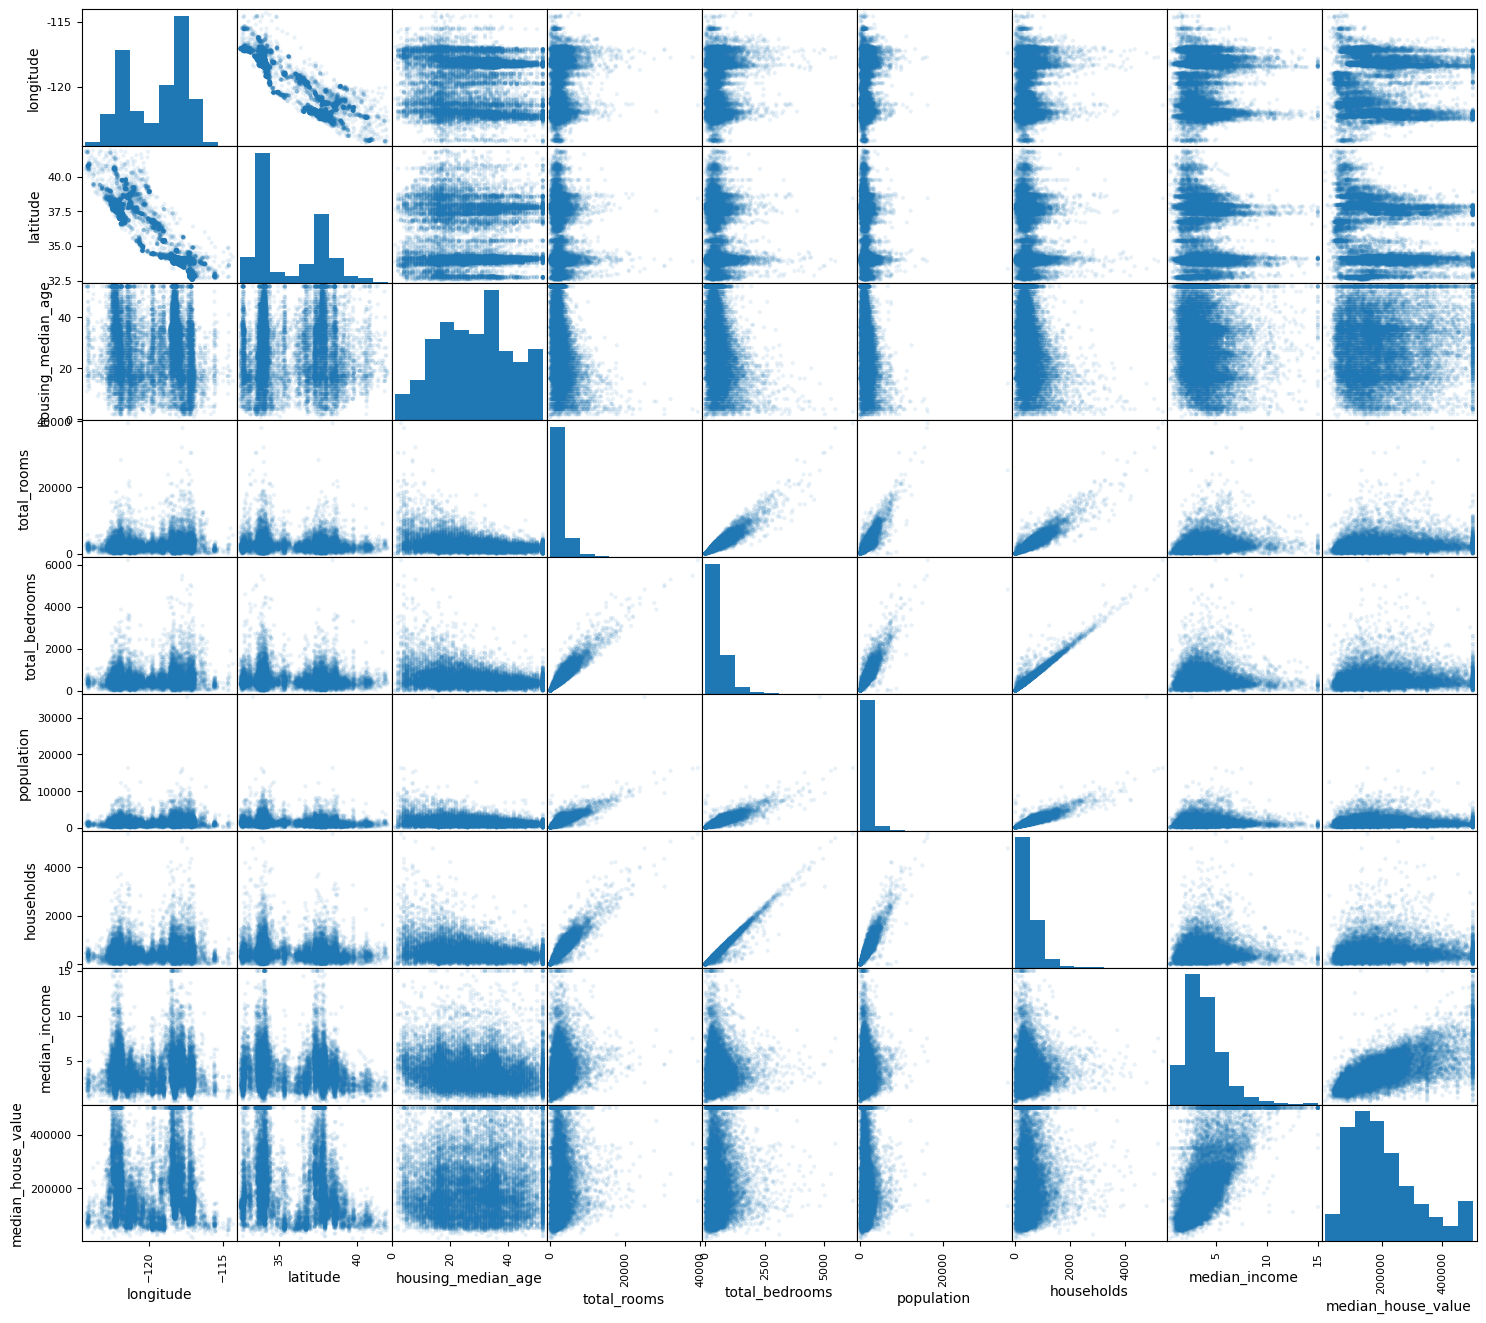

In [13]:
from pandas.plotting import scatter_matrix

numeric_housing = housing.select_dtypes(include="number")
scatter_matrix(numeric_housing, alpha=0.1, diagonal="hist", figsize=(18, 16))
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

<Axes: xlabel='median_income', ylabel='median_house_value'>

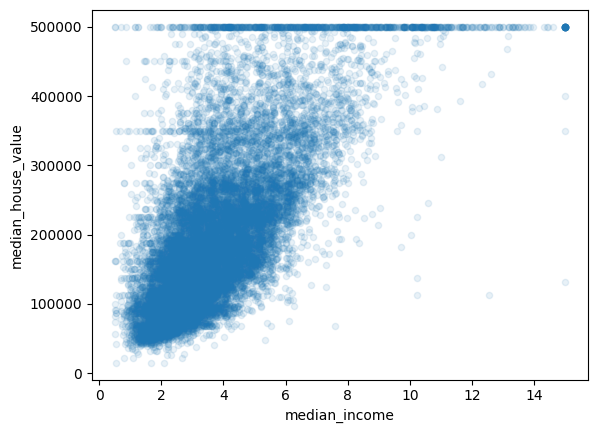

In [14]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

# How to create new features:
- Feature engineering is the process of creating new features from existing data to improve the performance of machine learning models.
- You can mix existing features, extract new features from existing ones, or create new features based on domain knowledge.

In [15]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"] = housing["population"]/housing["households"]

corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

# Preparing the data for machine learning algorithms:
- Tip: write functions to do transformations, so you can easily apply them to the training set and the test set.
- DRY principle: Don't Repeat Yourself. Avoid code duplication by creating reusable functions for data transformations.
- Easy to: fix, debug, and maintain the code when transformations are encapsulated in functions. If you need to change a transformation, you only need to update the function in one place, rather than searching through the code for every instance of that transformation.

## Cleaning the data:
- Most of the M.L. models don't work well with missing data, so you need to handle it before training the model.
- Common strategies for handling missing data:
    - Delete rows with missing values (not recommended if you have a lot of missing data). `dropna(), fillna(), drop()`
        - `dropna()`: removes rows with missing values.
        - `fillna()`: fills missing values with a specified value or method (e.g., mean, median, mode).
        - `drop()`: removes specified rows or columns from the DataFrame.
    - Impute missing values with mean, median, or mode (for numerical data) or with the most frequent value (for categorical data).
        - `SimpleImputer` from scikit-learn can be used for this purpose.
    - Use algorithms that can handle missing values (e.g., XGBoost, LightGBM).

In [16]:
from sklearn.impute import SimpleImputer

# Separate target from features to avoid data leakage
housing_labels = housing["median_house_value"].copy()
housing = housing.drop("median_house_value", axis=1)

# Separate numerical and categorical columns
housing_num = housing.drop("ocean_proximity", axis=1)

# Create an imputer object with a strategy to fill missing values with the median
imputer = SimpleImputer(strategy="median")

# Fit the imputer to the numerical data and compute the median values for each column
imputer.fit(housing_num)

# The imputer has computed the median values for each column and stored them in `statistics_`
print(imputer.statistics_)
print(housing_num.median().values)

[-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  5.23234164e+00  2.03027043e-01  2.81766108e+00]
[-1.18510000e+02  3.42600000e+01  2.90000000e+01  2.11900000e+03
  4.33000000e+02  1.16400000e+03  4.08000000e+02  3.54155000e+00
  5.23234164e+00  2.03027043e-01  2.81766108e+00]


In [17]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing.index)
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,5.485836,0.205784,3.168555
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,6.927083,0.160714,2.623698
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,5.393333,0.191595,2.223333
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,3.886128,0.276505,1.859213
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,6.096552,0.182692,3.167241


## SKLEARN DESIGN:
- Estimators: algorithms that can estimate some parameters based on a dataset. They have a `fit()` method that takes the training data and labels as input and learns from it.
    - toolbox that learn with the model and the data, and then can be used to make predictions or transformations.
    - Learning data patterns and relationships in the data, and then can be used to make predictions or transformations.
- Transformers: algorithms that can transform a dataset. They have a `transform()` method that takes the data as input and returns the transformed data. They also have a `fit_transform()` method that combines the `fit()` and `transform()` methods into one step.
    - Like a data translater, it takes the data and transforms it into a new format that can be used by the model.
- Predictors: algorithms that can make predictions based on a dataset. They have a `predict()` method that takes the data as input and returns the predicted labels.
    - Like a crystal ball, it takes the data and predicts the future based on what it has learned from the training data.
- Inspector: algorithms that can inspect a dataset and provide information about it. They have a `get_params()` method that returns the parameters of the algorithm and a `set_params()` method that allows you to set the parameters of the algorithm.
    - What the model really learned from the data, and how it is making predictions.
    - Like a detective, it investigates the data and provides insights about it, such as feature importance or model parameters.

### Categorical columns:
- Categorical data that represents text values.
- Common techniques for handling categorical columns:
    - One-hot encoding: creates a new binary column for each category in the original column. This is useful when there are a small number of categories.
    - Label encoding: assigns a unique integer to each category in the original column. This is useful when there are a large number of categories.
    - Target encoding: replaces each category with the mean of the target variable for that category. This can be useful when there are a large number of categories and the target variable is continuous.

In [18]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head()

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN


In [19]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded

array([[1.],
       [4.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]], shape=(16512, 1))

# The problem with label encoding:
- Some problems is that algorithms may interpret the encoded values as having an ordinal relationship, which may not be the case. For example, if you have a categorical variable "color" with categories "red", "green", and "blue", and you encode them as 0, 1, and 2 respectively, the algorithm may interpret "blue" as being greater than "green" and "red", which may not be true. To avoid this issue, it is important to choose the appropriate encoding technique based on the nature of the categorical variable and the requirements of the machine learning algorithm being used.

In [20]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
housing_cat_1hot = encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

# Attention with a lot of categories:
- If you have a categorical variable with a large number of categories, one-hot encoding can lead to a very large number of features, which can cause issues with memory and computational efficiency. In such cases, it may be better to use label encoding or target encoding, or to consider dimensionality reduction techniques to reduce the number of features.
- embedding: a technique used to represent categorical variables as dense vectors in a continuous vector space. This can be useful when dealing with high-cardinality categorical variables, as it can help to reduce the dimensionality of the data and improve the performance of machine learning models.
- embedding means:
    - It is a technique used to represent categorical variables as dense vectors in a continuous vector space. This can be useful when dealing with high-cardinality categorical variables, as it can help to reduce the dimensionality of the data and improve the performance of machine learning models.

## Customize your transformers:
- You can create your own transformers by creating a class that inherits from `BaseEstimator` and `TransformerMixin` from scikit-learn. This allows you to define your own `fit()` and `transform()` methods, which can be used to perform custom data transformations that are not available in scikit-learn's built-in transformers.
- Duck type:
    - It is a programming concept that allows an object to be treated as an instance of a particular class based on its behavior rather than its actual type. In the context of scikit-learn, this means that as long as your custom transformer has the necessary methods (e.g., `fit()`, `transform()`, `fit_transform()`), it can be used in the same way as any other transformer in scikit-learn, regardless of its underlying implementation. This allows for greater flexibility and extensibility when creating custom transformers for machine learning pipelines.
    - If walks like a duck and quacks like a duck, then it is a duck. In the context of scikit-learn, this means that if an object has the necessary methods (e.g., `fit()`, `transform()`, `fit_transform()`), it can be used as a transformer in a machine learning pipeline, regardless of its actual class or implementation. This allows for greater flexibility and extensibility when creating custom transformers for machine learning pipelines.
    - fit and transform methods are the key to making a custom transformer compatible with scikit-learn's pipeline and other tools. By implementing these methods, you can ensure that your custom transformer can be used seamlessly with other scikit-learn components, allowing for easy integration into machine learning workflows.

- Base Estimator: organize the code (parameters model) as a base class in scikit-learn that provides a common interface for all estimators (algorithms that can estimate some parameters based on a dataset). It includes methods such as `get_params()` and `set_params()` for accessing and modifying the parameters of the estimator.
    - Easy to set and get parameters of the estimator, which is useful for hyperparameter tuning and model selection. By inheriting from `BaseEstimator`, your custom transformer can take advantage of these features and be easily integrated into scikit-learn's ecosystem.
    - AVOID use args e kwargs in the constructor of your custom transformer, as it can make it difficult to understand and use the transformer. Instead, explicitly define the parameters in the constructor and provide default values if necessary. This will make it easier for users to understand how to use your custom transformer and will also allow for better integration with scikit-learn's tools for hyperparameter tuning and model selection.
    - ARGS: Posicional arguments, 1,2,3..., a variable-length argument list that allows you to pass a variable number of non-keyword arguments to a function or method. It is denoted by `*args` in the function definition.
    - KWARGS: Namings arguments, a variable-length keyword argument list that allows you to pass a variable number of keyword arguments to a function or method. It is denoted by `**kwargs` in the function definition.
    - Breaks gridsearching view : if you use `*args` and `**kwargs` in the constructor of your custom transformer, it can make it difficult for tools like GridSearchCV to understand the parameters of your transformer and perform hyperparameter tuning effectively. This is because GridSearchCV relies on the ability to access and modify the parameters of the estimator using the `get_params()` and `set_params()` methods, which may not work properly if the parameters are not explicitly defined in the constructor. By avoiding the use of `*args` and `**kwargs`, you can ensure that your custom transformer is compatible with scikit-learn's tools for hyperparameter tuning and model selection.

- `get_params()`: a method in scikit-learn that returns the parameters of an estimator (algorithm that can estimate some parameters based on a dataset) as a dictionary. This method is useful for accessing the parameters of an estimator and for performing hyperparameter tuning and model selection.
- `set_params()`: a method in scikit-learn that allows you to set the parameters of an estimator. This method is useful for modifying the parameters of an estimator and for performing hyperparameter tuning and model selection. By using `set_params()`, you can easily update the parameters of your custom transformer and ensure that it works seamlessly with scikit-learn's tools for hyperparameter tuning and model selection.

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

# Each more automate i earn more possibility to make a mistake, so be careful with this kind of code.

room_ix, bedroom_ix, population_ix, household_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    """ArithmeticError

    This transformer adds new combined attributes to the dataset, such as rooms per household, 
        population per household, and optionally bedrooms per room. It inherits from BaseEstimator 
        and TransformerMixin to be compatible with scikit-learn pipelines.

    Args:
        add_bedrooms_per_room (bool): If True, adds the bedrooms per room attribute to the dataset. Default is True.
    
    Methods:
        fit(X, y=None): This method is required for compatibility with scikit-learn pipelines
            but does not perform any fitting. It simply returns the transformer instance.
        transform(X): This method takes the input dataset X and computes the new combined attributes.
            It calculates rooms per household, population per household, and optionally bedrooms per room, 
            and returns a new dataset with these attributes added as new columns.
    Returns:
        numpy.ndarray: A new dataset with the combined attributes added as new columns.
    """
    def __init__(self, add_bedrooms_per_room=True):  # no *args or **kwargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, room_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedroom_ix] / X[:, room_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                        bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]
        
attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

# Escale Caracteristics (Normalization):
- Minmax Scaler: scales the data to a fixed range, usually [0, 1]. It is sensitive to outliers.
- Standard Scaler: scales the data to have a mean of 0 and a standard deviation of 1. It is less sensitive to outliers than Minmax Scaler.
    - Mean values are equal zero, and the standard deviation is 1. This can be useful when the data is normally distributed or when you want to ensure that all features have the same variance for certain machine learning algorithms (e.g., SVM, logistic regression).
- Robust Scaler: scales the data using statistics that are robust to outliers, such as the median and the interquartile range. It is useful when the data contains many outliers.

# Pipeline Transformations:
- A pipeline is a way to chain multiple data transformations and model training steps together in a single object. This allows you to streamline the process of data preprocessing and model training, and also makes it easier to apply the same transformations to new data when making predictions.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sum_pipeline = Pipeline([
    # SimpleImputer: fills in missing values with the median of each column.
    ('imputer', SimpleImputer(strategy="median")),
    # CombinedAttributesAdder: adds new features to the dataset based on existing features.
    ('attribs_adder', CombinedAttributesAdder()),
    # StandardScaler: standardizes the features by removing the mean and scaling to unit variance.
    ('std_scaler', StandardScaler()),
])
housing_num_tr = sum_pipeline.fit_transform(housing_num)

## The ColumnTransformer:
- It is a transformer in scikit-learn that allows you to apply different transformations to different
- Numerical and Categorical toghether.
- It is useful when you have a dataset with both numerical and categorical features, and you want to apply different preprocessing steps to each type of feature. For example, you might want to apply a StandardScaler to the numerical features and a OneHotEncoder to the categorical features. The ColumnTransformer allows you to specify which transformations to apply to which columns in a single step, making it easier to manage your data preprocessing pipeline.

In [23]:
from sklearn.compose import ColumnTransformer
# list of the numerical and categorical attributes
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", sum_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)

## The pass through / passthrough (column pass transformer bypass):
- It is a special value that can be used in scikit-learn's `ColumnTransformer
` to indicate that certain columns should be passed through without any transformation. This can be useful when you want to include certain features in your model without applying any preprocessing steps to them. By using the `passthrough` option, you can ensure that these columns are included in the output of the `ColumnTransformer` and can be used by the machine learning model without any modifications.

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge  # Example model with L2 regularization

# Local transformer definition so this cell runs independently
room_ix, bedroom_ix, population_ix, household_ix = 3, 4, 5, 6
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:, room_ix] / X[:, household_ix]
        population_per_household = X[:, population_ix] / X[:, household_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedroom_ix] / X[:, room_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        return np.c_[X, rooms_per_household, population_per_household]

# Lists of numerical and categorical columns
num_attribs = list(housing_num)  # your numerical columns
cat_attribs = ["ocean_proximity"]

# Pipeline for numerical columns
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("std_scaler", StandardScaler()),
])

# Apply the numerical pipeline to numerical columns and OneHotEncoder to categorical columns,
# while also passing one specific column through unchanged
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
    ("pass_through_col", "passthrough", ["population"])  # "population" is passed through as-is
])

housing_prepared = full_pipeline.fit_transform(housing)

## Get and Set Parameters:
- `get_params()`: a method in scikit-learn that returns the parameters of an
- estimator (algorithm that can estimate some parameters based on a dataset) as a dictionary. This method is useful for accessing the parameters of an estimator and for performing hyperparameter tuning and model selection.
- `set_params()`: a method in scikit-learn that allows you to set the
- parameters of an estimator. This method is useful for modifying the parameters of an estimator and for performing hyperparameter tuning and model selection. By using `set_params()`, you can easily update the parameters of your custom transformer and ensure that it works seamlessly with scikit-learn's tools for hyperparameter tuning and model selection.

In [25]:
# 1. Get all parameters from the pipeline
params = full_pipeline.get_params()
print("All pipeline parameters:")
for name, param in params.items():
    print(name, ":", param)

# 2. Set a nested parameter using set_params
full_pipeline.set_params(
    num__attribs_adder__add_bedrooms_per_room=False  # Disable bedrooms_per_room in the numeric pipeline
)

# 3. Fit the pipeline again after updating the parameter
full_pipeline.fit(housing)

# 4. Check parameters again to confirm the update
updated_params = full_pipeline.get_params()
print("Updated pipeline parameters:")
print("num__attribs_adder__add_bedrooms_per_room:", updated_params["num__attribs_adder__add_bedrooms_per_room"])

All pipeline parameters:
force_int_remainder_cols : deprecated
n_jobs : None
remainder : drop
sparse_threshold : 0.3
transformer_weights : None
transformers : [('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('attribs_adder', CombinedAttributesAdder()),
                ('std_scaler', StandardScaler())]), ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']), ('cat', OneHotEncoder(), ['ocean_proximity']), ('pass_through_col', 'passthrough', ['population'])]
verbose : False
verbose_feature_names_out : True
num : Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('attribs_adder', CombinedAttributesAdder()),
                ('std_scaler', StandardScaler())])
cat : OneHotEncoder()
pass_through_col : passthrough
num__memory : None
num__steps : [('imputer', SimpleImputer(strategy='me

# Choosing and trainig your pipeline:
- After you have defined your data preprocessing steps and your machine learning model, you can create a pipeline that combines these steps together. This allows you to streamline the process of training your model and makes it easier to apply the same transformations to new data when making predictions. To train your pipeline, you can use the `fit()` method, which will fit the entire pipeline to the training data. Once the pipeline is fitted, you can use the `predict()` method to make predictions on new data.

## Remenbering Linear Regression:
# 🤖 Foundation Review: Multiple Linear Regression via Linear Algebra

In this notebook, we recap the implementation of the **Normal Equation**, the mathematical bedrock for finding regression coefficients without iterative methods (like Gradient Descent), using pure matrix operations.

---

## 1. Defining Input Data

We are working with 3 samples and 3 features ($A, B, C$). To include the **intercept ($\beta_0$)**, we prepend a column of **1s** to our design matrix $X$.

### Design Matrix ($X$) and Target Vector ($D$)
$$X = \begin{bmatrix} 1 & 1 & 2 & 3 \\ 1 & 2 & 3 & 4 \\ 1 & 3 & 4 & 5 \end{bmatrix}, \quad D = \begin{bmatrix} 10 \\ 15 \\ 20 \end{bmatrix}$$

> **MLE Note:** Notice that $B = A + 1$ and $C = B + 1$. This characterizes **Perfect Multicollinearity**, which directly impacts matrix inversion. ⚠️

---

## 2. The Mathematical Workflow

To solve for the weight vector $\beta$, we apply the Normal Equation formula:
$$\beta = (X^T X)^{-1} X^T D$$

### Step A: Transpose of $X$ ($X^T$)
We swap rows and columns to enable matrix multiplication:
$$X^T = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 2 & 3 \\ 2 & 3 & 4 \\ 3 & 4 & 5 \end{bmatrix}$$

### Step B: The Gram Matrix ($X^T X$)
Computing the (unscaled) covariance matrix:
$$X^T X = \begin{bmatrix} 3 & 6 & 9 & 12 \\ 6 & 14 & 20 & 26 \\ 9 & 20 & 29 & 38 \\ 12 & 26 & 38 & 50 \end{bmatrix}$$

### Step C: The Cross-Product ($X^T D$)
$$X^T D = \begin{bmatrix} 45 \\ 100 \\ 145 \\ 190 \end{bmatrix}$$

---

## 3. Final Result & Diagnosis 🧠

Due to the linear dependence between columns, $\text{det}(X^T X) = 0$. In a real-world scenario, the model would not have a unique solution. Using the **Moore-Penrose Pseudoinverse**, the balanced coefficients would be:

$$\beta \approx \begin{bmatrix} 0 \\ 1.667 \\ 1.667 \\ 1.667 \end{bmatrix}$$

### 💡 Expert Insights:
1. **Regularization:** If you encounter singular matrices, use **Ridge Regression** ($L2$) to add a small value to the diagonal of $X^T X$, making it invertible.
2. **Redundancy:** Always check the VIF (*Variance Inflation Factor*) to remove highly correlated features before training.
3. **Scaling:** Remember that $X^T X$ is highly sensitive to the scale of your features!

---

In [26]:
from sklearn.linear_model import LinearRegression

# Use current pipeline configuration on features only
housing_prepared = full_pipeline.fit_transform(housing)

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [ 83648.54287152 305815.0882093  150013.37994426 188096.42566946
 241840.13952576]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


## The RMSE (Root Mean Squared Error)(outlier detector) is a common metric for evaluating the performance of regression models. It measures the average magnitude of the errors between predicted and actual values, giving more weight to larger errors. The formula for RMSE is:
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

Where:
- $n$ is the number of observations
- $y_i$ is the actual value for the $i$-th observation
- $\hat{y}_i$ is the predicted value for the $i$-th observation

## The MAE (Mean Absolute Error) is another common metric for evaluating the performance of regression models. It measures the average magnitude of the errors between predicted and actual values, giving equal weight to all errors. The formula for MAE is:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Where:
- $n$ is the number of observations
- $y_i$ is the actual value for the $i$-th observation
- $\hat{y}_i$ is the predicted value for the $i$-th observation

# The R² (R-squared) (real values changing with the mean) is a statistical measure that represents the proportion of the variance in the dependent variable that is predictable from the independent variables. It is a value between 0 and 1, where a higher value indicates a better fit of the model to the data. The formula for R² is:
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
    - How much of the variance in the dependent variable is explained by the independent variables in the model.
    - No direction or magnitude of the relationship between the variables, just how well the model fits the data.
    
Where:
- $SS_{res}$ is the sum of squares of residuals (the difference between actual and predicted values)
    - $SS_{res} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$
- $SS_{tot}$ is the total sum of squares (the difference between actual values and the mean of actual values)
    - $SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2$
- $y_i$ is the actual value for the $i$-th observation
- $\hat{y}_i$ is the predicted value for the $i$-th observation
- $\bar{y}$ is the mean of the actual values

In [28]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68160.92435491859)

## Decision Trees (Classification)
A Decision Tree is a non-parametric supervised learning method used for classification and regression. It predicts the value of a target variable by learning simple decision rules inferred from the data features.

### Gini Impurity (The standard for CART)
Gini Impurity measures the frequency at which a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. It favors larger partitions and is computationally efficient.

$$
Gini = 1 - \sum_{i=1}^{J} p_i^2
$$
Where:
- $p_i$ is the probability of an object being classified into a particular class.

### Entropy and Information Gain (The ID3/C4.5 approach)
Entropy is a measure of disorder or uncertainty in the dataset. Information Gain calculates the reduction in entropy after a dataset is split on an attribute.

$$
Entropy(S) = - \sum_{i=1}^{c} p_i \log_2 p_i
$$

$$
Information\ Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} Entropy(S_v)
$$
Where:
- $S$ is the current dataset.
- $A$ is the feature being tested.
- $p_i$ is the proportion of elements in class $i$ relative to the total number of elements.

### Key Concepts to Watch Out For
- **Overfitting:** Decision trees are notorious for creating over-complex trees that do not generalize well.
- **Pruning:** A technique to reduce the size of decision trees by removing sections of the tree that provide little power to classify instances.

### Hyperparameters
- `max_depth`: Limits how deep the tree can go.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `ccp_alpha`: Used for Cost Complexity Pruning.

### Minhas Considerações de Especialista 🧐
- **Gini vs Entropy:** Na prática (Scikit-Learn, por exemplo), o Gini é o padrão porque não exige o cálculo de logaritmos, sendo mais rápido. No entanto, os resultados costumam ser muito parecidos.
- **Bias-Variance Tradeoff:** Árvores sozinhas têm high variance (variam muito com pequenas mudanças nos dados). Por isso que no mundo real a gente raramente usa uma árvore "solteira" e prefere Random Forests ou XGBoost.
- **Feature Scaling:** Uma das maiores vantagens das árvores? Você não precisa de escalonamento de features (`StandardScaler`/`MinMaxScaler`). Elas são imunes à escala das variáveis porque as divisões são baseadas em limiares (thresholds). 🎨

## The Decision tree:
- A decision tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. It works by recursively splitting the data into subsets based on the values of the features, creating a tree-like structure where each internal node represents a feature and each leaf node represents a predicted outcome.
- The decision tree algorithm uses a measure of impurity (such as Gini impurity or entropy) to determine the best feature and threshold for splitting the data at each node. The goal is to create branches that lead to the most homogeneous subsets of the target variable, ultimately resulting in a tree that can make accurate predictions on new data. Decision trees are easy to interpret and can capture complex relationships between features, but they can also be prone to overfitting if not properly pruned or regularized.
- The decision tree algorithm can be used for both classification and regression tasks. In classification, the tree predicts the class label for a given input, while in regression, it predicts a continuous value. The algorithm works by recursively splitting the data based on the values of the features, creating a tree-like structure where each internal node represents a feature and each leaf node represents a predicted outcome. The decision tree can capture complex relationships between features and is easy to interpret, but it can also be prone to overfitting if not properly pruned or regularized.

# Training and avaluating the model:

In [29]:
from sklearn.linear_model import LinearRegression

lin_req = LinearRegression()
lin_req.fit(housing_prepared, housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Linear Regression:

In [30]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_req.predict(some_data_prepared))

some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_req.predict(some_data_prepared))
print("Actual labels:", some_labels.values)

from sklearn.metrics import mean_squared_error
housing_predictions = lin_req.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

Predictions: [ 83648.54287152 305815.0882093  150013.37994426 188096.42566946
 241840.13952576]
Predictions: [ 83648.54287152 305815.0882093  150013.37994426 188096.42566946
 241840.13952576]
Actual labels: [ 72100. 279600.  82700. 112500. 238300.]
68160.92435491859


## Decision Tree:

In [31]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
print(tree_mse)
tree_rmse = np.sqrt(tree_mse)
print(tree_rmse)

0.0
0.0


## Cross-Validation (CV): The Gold Standard for Model Evaluation

Cross-validation is a robust statistical resampling technique used to estimate how well a machine learning model generalizes to unseen data. Instead of trusting a single train/test split, CV rotates validation folds so each sample is used for both training and validation across iterations.

### Why It Is Non-Negotiable for MLEs
- **Reduces variance in evaluation:** lowers the chance of overestimating performance from a lucky split.
- **Supports hyperparameter tuning:** it is the core mechanism behind `GridSearchCV` and `RandomizedSearchCV`.
- **Improves data efficiency:** essential when dataset size is limited and a large hold-out set is expensive.

### Comparison of CV Techniques

| Method | Mechanism | Best Use Case | Expert Opinion |
|---|---|---|---|
| **K-Fold** | Splits data into $K$ equal folds; trains $K$ times, each time validating on one fold. | General, balanced datasets. | Industry default. $K=5$ or $K=10$ usually gives a strong bias-variance tradeoff. |
| **Stratified K-Fold** | Preserves class proportions in every fold. | Imbalanced classification. | Mandatory for classification with skewed classes; avoids minority-class blindness in folds. |
| **Leave-One-Out (LOO)** | Sets $K=N$ (one sample as validation per iteration). | Very small datasets ($N < 100$). | Statistically appealing, but computationally expensive for larger datasets. |
| **TimeSeriesSplit** | Expanding-window split that respects time order. | Forecasting (finance, IoT, weather, demand). | Critical for temporal data; standard K-Fold leaks future information. |

### 5-Fold Cross-Validation Process

| Iteration | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | Metric |
|---|---|---|---|---|---|---|
| 1 | **TEST** | TRAIN | TRAIN | TRAIN | TRAIN | $E_1$ |
| 2 | TRAIN | **TEST** | TRAIN | TRAIN | TRAIN | $E_2$ |
| 3 | TRAIN | TRAIN | **TEST** | TRAIN | TRAIN | $E_3$ |
| 4 | TRAIN | TRAIN | TRAIN | **TEST** | TRAIN | $E_4$ |
| 5 | TRAIN | TRAIN | TRAIN | TRAIN | **TEST** | $E_5$ |

**Final score:**

$$
\text{CV Score} = \frac{1}{5}\sum_{i=1}^{5} E_i
$$

This average gives a more reliable estimate of out-of-sample performance than a single split.

In [32]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [72110.0441234  71390.80577491 67120.74615879 73520.38790677
 69265.80811361 74922.43793535 71131.31853808 73216.24622061
 69183.16178918 71665.61362533]
Mean: 71352.65701860326
Standard deviation: 2204.7244329802998


### `Atention`: avaragen and standard deviation of the CV scores are both important. 
- A high standard deviation may indicate that the model's performance is `unstable` across different subsets of the data, which could be a sign of overfitting or sensitivity to specific data points. 
- Always consider both metrics when evaluating your model's performance.

In [33]:
lin_score = cross_val_score(lin_reg, housing_prepared, housing_labels, cv=5, scoring='neg_mean_squared_error')
lin_rmse_scores = np.sqrt(-lin_score)
print("Linear Regression CV RMSE Scores:", lin_rmse_scores)
print("Linear Regression CV RMSE Mean:", lin_rmse_scores.mean())
print("Linear Regression CV RMSE Standard Deviation:", lin_rmse_scores.std())

Linear Regression CV RMSE Scores: [67609.56917321 67668.73748845 69483.59713542 69315.39303326
 68092.25359621]
Linear Regression CV RMSE Mean: 68433.9100853106
Linear Regression CV RMSE Standard Deviation: 807.540870743214


lin_score = cross_val_score(lin_reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
lin_rmse_scores = np.sqrt(-lin_score)
print("Linear Regression CV RMSE Scores:", lin_rmse_scores)

## Random Forest: The Power of the Ensemble

Random Forest is an ensemble learning method that builds many Decision Trees during training and aggregates their predictions. It follows the **Bagging (Bootstrap Aggregating)** principle: instead of relying on one tree, it uses a diverse set of trees and combines them by majority vote (classification) or averaging (regression).

### Why It Is an MLE Favorite
- **Handles non-linearity well:** captures complex feature interactions without requiring feature scaling.
- **Robust to outliers:** aggregation reduces the impact of extreme observations from individual trees.
- **Built-in internal validation:** supports **Out-of-Bag (OOB) error**, which acts like a free internal validation estimate.

### Decision Tree vs. Random Forest

| Feature | Single Decision Tree | Random Forest | Expert Opinion |
|---|---|---|---|
| **Variance** | High (prone to overfitting) | Low (better generalization) | Trees are greedy; forests are wiser. |
| **Interpretability** | High (easy to inspect) | Lower (more black-box) | Use feature importance or SHAP for interpretability. |
| **Data Sensitivity** | High (small data changes can produce very different trees) | Low (stable due to bootstrapping) | Stability is essential in production pipelines. |
| **Training Speed** | Fast | Slower (trains $N$ trees) | Highly parallelizable with `n_jobs=-1`. |

### How It Works: The Two Pillars of Randomness

| Mechanism | Description | Purpose |
|---|---|---|
| **Bootstrapping** | Each tree is trained on a random sample of rows **with replacement**. | Ensures each tree learns from a slightly different data view. |
| **Feature Randomness** | At each split, the tree evaluates only a random subset of features. | Prevents one dominant feature from controlling all trees. |

### Practical Notes for Regression
- Start with `n_estimators` between 200 and 500 for stable performance.
- Tune `max_depth`, `min_samples_split`, and `min_samples_leaf` to control overfitting.
- Enable `oob_score=True` (with `bootstrap=True`) for fast internal validation.

In [35]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(housing_prepared, housing_labels)
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)


forest_score = cross_val_score(forest_reg, housing_prepared, housing_labels, cv=5, scoring='neg_mean_squared_error')
forest_rmse_scores = np.sqrt(-forest_score)
print("Random Forest CV RMSE Scores:", forest_rmse_scores)
print("Random Forest CV RMSE Mean:", forest_rmse_scores.mean())
print("Random Forest CV RMSE Standard Deviation:", forest_rmse_scores.std())

18658.548497759144
Scores: 18658.548497759144
Mean: 18658.548497759144
Standard deviation: 0.0
Random Forest CV RMSE Scores: [50127.04090776 49813.25781958 50039.22123337 51634.77603479
 51602.70110294]
Random Forest CV RMSE Mean: 50643.399419687994
Random Forest CV RMSE Standard Deviation: 802.9794246869571
